In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = "/content/drive/MyDrive/Dataset.zip"

In [4]:
!unzip "/content/drive/MyDrive/Dataset.zip" -d "/content/dataset"


Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a3938779-9d9f-4e45-a397-7b5abd13f6ba___JR_Sept.L.S 2700.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a4467299-5237-45f5-bb9b-9fd69f7a2b1a___Matt.S_CG 7719.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a45b192c-f31e-4ca1-bf4a-10ff1060e658___Matt.S_CG 7512.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a45bce54-4c25-4d5d-a9a9-fbc76436844c___Matt.S_CG 6523.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a46ff722-2186-4645-9018-01e8e20cfa2a___Matt.S_CG 6511.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a4880706-e191-43ff-a5a7-bd0f0c03aa2d___Keller.St_CG 1851.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a494e2ac-9dbe-47e5-9963-3e99f8eb9d2e___Matt.S_CG 6062.JPG  
  inflating: /content/dataset/Tomato/Train/Septoria Leaf Spot/a49c7f28-4b67-4d95-b79b-26a5

In [5]:
!ls /content/dataset


 Apple	        Cherry	        Grape   Potato	     Tomato
'Bell Pepper'  'Corn (Maize)'   Peach   Strawberry


In [6]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: []


In [7]:
DATASET_DIR = "/content/dataset"


In [8]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 67118 files belonging to 9 classes.
Using 53695 files for training.
Found 67118 files belonging to 9 classes.
Using 13423 files for validation.
Classes: ['Apple', 'Bell Pepper', 'Cherry', 'Corn (Maize)', 'Grape', 'Peach', 'Potato', 'Strawberry', 'Tomato']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,121 (42.61 MB)

 Trainable params: 11,170,121 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6327s 4s/step - accuracy: 0.6458 - loss: 1.0209 - val_accuracy: 0.9102 - val_loss: 0.2734
Epoch 2/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6302s 4s/step - accuracy: 0.9286 - loss: 0.2119 - val_accuracy: 0.9493 - val_loss: 0.1570
Epoch 3/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6322s 4s/step - accuracy: 0.9675 - loss: 0.0991 - val_accuracy: 0.9385 - val_loss: 0.1965
Epoch 4/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6266s 4s/step - accuracy: 0.9751 - loss: 0.0730 - val_accuracy: 0.9430 - val_loss: 0.2095
Epoch 5/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 6312s 4s/step - accuracy: 0.9796 - loss: 0.0603 - val_accuracy: 0.9519 - val_loss: 0.1931


# Task
Evaluate the trained model's performance on the validation dataset.

## Evaluate Model

### Subtask:
Evaluate the trained model's performance on the validation dataset to get the final loss and accuracy.


**Reasoning**:
The subtask is to evaluate the trained model on the validation dataset to get the final loss and accuracy. The model has already been trained and the validation dataset is available as `val_ds`. I will use the `model.evaluate()` method to perform this action.



In [13]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

420/420 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9515 - loss: 0.2093
Validation Loss: 0.1931
Validation Accuracy: 0.9519


## Visualize Training History

### Subtask:
Plot the training and validation accuracy and loss curves over the epochs to analyze the model's learning process and identify potential overfitting or underfitting. Include legends for clarity.


**Reasoning**:
The subtask is to plot the training and validation accuracy and loss curves. I need to use `matplotlib.pyplot` to create these plots based on the `history` object, which contains the training logs.



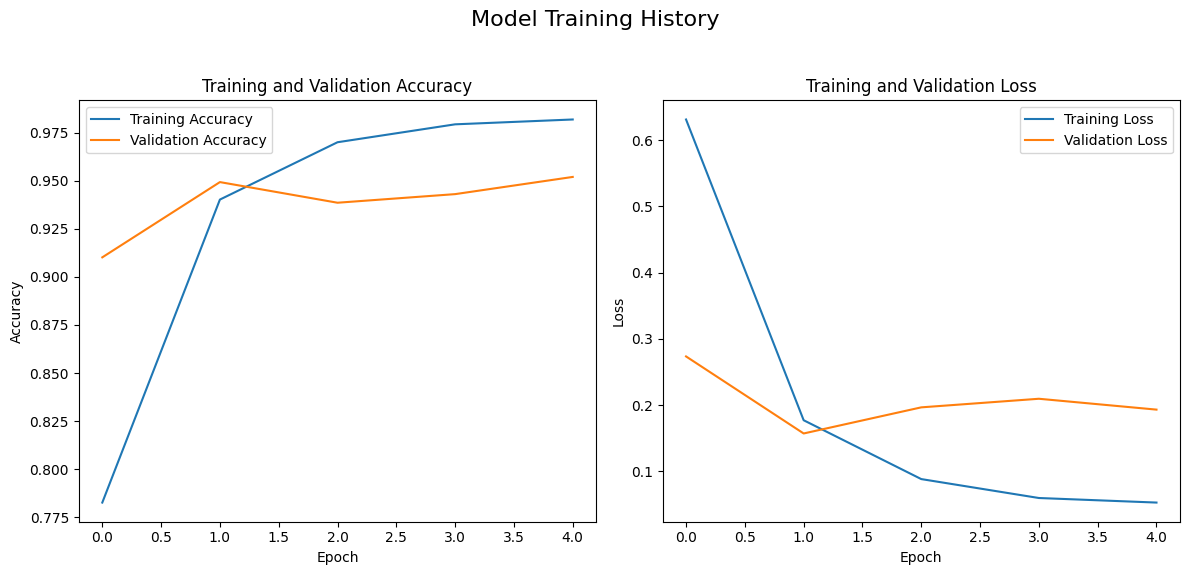

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.suptitle('Model Training History', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## Predict on Sample Image

### Subtask:
Take a sample image from the validation set, preprocess it, and use the trained model to predict its class. Display the image along with its predicted label.


**Reasoning**:
The subtask requires taking a sample image from the validation set, preprocessing it, using the trained model to predict its class, and displaying the image along with its predicted label. The provided instructions detail each step to achieve this, so I will generate a code block to execute them.



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step


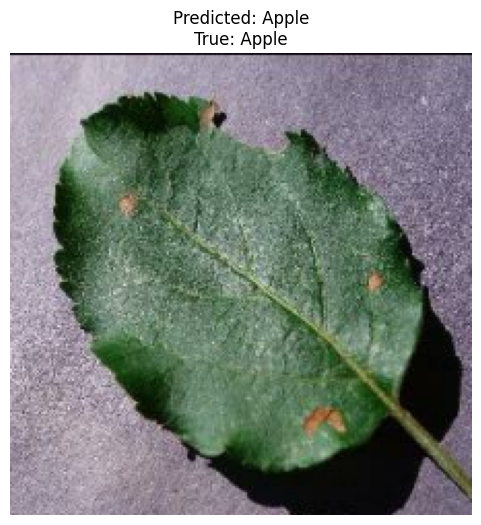

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get a batch of images and labels from the val_ds
images, labels = next(iter(val_ds))

# 2. Select a single image and its corresponding true label
sample_image = images[0].numpy()
true_label_index = labels[0].numpy()
true_label_name = class_names[true_label_index]

# 3. Expand the dimensions of the sample_image to create a batch of a single image for prediction
sample_image_batch = tf.expand_dims(sample_image, 0)

# 4. Use the trained model to predict the class probabilities for sample_image_batch
predictions = model.predict(sample_image_batch)

# 5. Get the predicted class by finding the index of the maximum probability
predicted_label_index = tf.argmax(predictions[0]).numpy()

# 6. Retrieve the human-readable predicted class name from class_names
predicted_label_name = class_names[predicted_label_index]

# 7. Display the sample_image
plt.figure(figsize=(6, 6))
plt.imshow(sample_image.astype('uint8'))

# 8. Add a title to the plot showing both the predicted and true labels
plt.title(f"Predicted: {predicted_label_name}\nTrue: {true_label_name}")
plt.axis('off')

# 9. Display the plot
plt.show()


## Final Task

### Subtask:
Summarize the model's performance based on the evaluation metrics and training history, and provide insights from the sample prediction.


## Summary:

### Data Analysis Key Findings

*   The model achieved a validation loss of approximately $0.1931$ and a validation accuracy of about $0.9519$.
*   The training history plots were successfully generated, visually representing the model's learning process, including training and validation accuracy and loss curves over epochs.
*   The model successfully predicted the class of a sample image from the validation set, with the output displaying both the predicted and true labels for comparison.

### Insights or Next Steps

*   The high validation accuracy ($95.19\%$) suggests the model is performing well on unseen data, indicating good generalization capabilities for the task of image classification.
*   Further analysis of the training history plots (accuracy and loss curves) is recommended to identify potential signs of overfitting or underfitting (e.g., a large gap between training and validation accuracy/loss, or plateaus) to inform potential model improvements.
